# Deep Learning 1 &mdash; Assignment 1

First assignment for the 2025 Deep Learning Part 1 course (NWI-IMC070A) of the Radboud University.

-----

**Names:** Nele Haferkorn

**Group:** 13

-----

**Instructions:**
* Fill in your names and the name of your group.
* Answer the questions and complete the code where necessary.
* Keep your answers brief, one or two sentences is usually enough.
* Re-run the whole notebook before you submit your work.
* Save the notebook as a PDF and submit that in Brightspace together with the `.ipynb` notebook file.
* The easiest way to make a PDF of your notebook is via File > Print Preview and then use your browser's print option to print to PDF.

## Objectives

In this assignment you will
1. Experiment with gradient descent optimization;
2. Derive and implement gradients for binary cross-entropy loss, the logistic sigmoid function and a linear layer;
3. Test your gradient implementations with the finite difference method;
4. Use these components to implement and train a simple neural network.

In [ ]:
%matplotlib inline
import scipy.optimize
import sklearn.datasets
import matplotlib.pyplot as plt
import torch
import math
from collections import namedtuple

plt.style.use('ggplot')

## 1.1 Gradient descent optimization (6 points)

Consider the following function with two parameters and its partial derivatives:

\begin{align}
  f(x, y) &= x^2 + y^2 + x (y + 2) + \cos(3x) \\
  \frac{\partial f}{\partial x} &= 2x - 3\sin(3x) + y + 2 \\
  \frac{\partial f}{\partial y} &= x + 2y \\
\end{align}

In [ ]:
def f(x, y):
    return x ** 2 + y ** 2 + x * (y + 2) + cos(3 * x)
def grad_x_f(x, y):
    return 2 * x - 3 * sin(3 * x) + y + 2
def grad_y_f(x, y):
    return x + 2 * y

In [ ]:
# Make sure that the functions work both with torch.Tensors as well as normal numbers
# Usually you would just do everything with Tensors
def cos(x):
    if isinstance(x, torch.Tensor):
        return torch.cos(x)
    else:
        return math.cos(x)

def sin(x):
    if isinstance(x, torch.Tensor):
        return torch.sin(x)
    else:
        return math.sin(x)

A plot of the function shows that it has multiple local minima:

In [ ]:
def plot_f_contours():
    xx, yy = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100), indexing='ij')
    zz = f(xx, yy)
    plt.contourf(xx, yy, zz, 50)
    plt.contour(xx, yy, zz, 50, alpha=0.2, colors='black', linestyles='solid')
    plt.xlabel('x')
    plt.ylabel('y')

plt.figure(figsize=(7, 7))
plot_f_contours()

### Implement gradient descent

We would like to find the minimum of this function using gradient descent.

**(a) Implement the gradient descent updates for $x$ and $y$ in the function below:<span style="float:right"> (1 point)</span>**

In [ ]:
dx = grad_x_f(3, 2)
dx

Ah I guess, I need to multiply the gradient value by the step size (which corresponds to the learning rate).

# Implementing gradient descent with Python (describe the steps)

In [ ]:
def optimize_f(x, y, step_size, steps):
    # keep track of the parameters we tried so far
    x_hist, y_hist = [x], [y]

    # run gradient descent for the number of steps
    for step in range(steps):
        # compute the gradients at the current point
        dx = grad_x_f(x, y)
        dy = grad_y_f(x, y)

        # apply the gradient descent updates to x and y
        x = x - step_size * abs(dx)  
        y = y - step_size* abs(dy)

        # store the new parameters
        x_hist.append(x)
        y_hist.append(y)

    return x, y, f(x, y), x_hist, y_hist

In [ ]:
# The following assert statements check that your implementation behaves sensibly
# Use it to get a hint only if you are stuck.
assert optimize_f(3, 2, 0.1, 1)[0] != 3, "Hint: you are not changing `x`"
assert optimize_f(3, 2, 0.1, 1)[2] < f(3, 2), "Hint: the function value is increasing, you should be minimizing it, not maximizing."
assert abs(optimize_f(3, 2, 0.1, 1)[0] - 3) < 1, "Hint: you are probably taking steps that are too large."

### Tune the parameters

We will now try if our optimization method works.

Use this helper function to plot the results:

In [ ]:
# helper function that plots the results of the gradient descent optimization
def plot_gradient_descent_results(x, y, val, x_hist, y_hist):
    # plot the path on the contour plot
    plt.figure(figsize=(12, 6), layout='constrained')
    plt.subplot(1, 2, 1)
    plot_f_contours()
    plt.plot(x_hist, y_hist, '.-')
    
    # plot the learning curve
    plt.subplot(1, 2, 2)
    plt.plot(f(torch.tensor(x_hist), torch.tensor(y_hist)), '.r-')
    plt.title('Minimum value: %f' % f(x_hist[-1], y_hist[-1]))

**(b) Run the gradient descent optimization with the following initial settings:**

``x=3, y=2, step_size=0.1, steps=10``

In [ ]:
results = optimize_f(x=3, y=2, step_size=0.1, steps=10)
plot_gradient_descent_results(*results)

**(c) Does it find the minimum of the function? What happens?<span style="float:right"> (1 point)</span>**

[a] Yes, the optimization finds the minimum.  
[b] No, the optimization ends in a local minimum, where it gets stuck.  
[c] No, the optimization ends too soon, before it reaches the minimum.  
[d] No, the optimization ends in a saddle point, where the graditient of the function is 0.  

TODO: Select one answer:  
[b] The optimization ends in a local minimum, where it gets stuck

**(d) Try a few different values for the `step_size` and the number of `steps` to get close to the optimal solution:**

In [ ]:
# TODO: tune the parameters to find a better optimum
results = optimize_f(x=3, y=2, step_size=0.1, steps=10)
plot_gradient_descent_results(*results)
assert results[2] < -1.5, "You should have a better result"

In [ ]:
# implement a for loop to compare this

# create list of step_sizes
step_sizes = [0.001, 0.01, 0.025, 0.05, 0.2]
results = []

for step_size in step_sizes:
    result = optimize_f(x=3, y=2, step_size=step_size, steps=700)
    results.append(result)

print(results)

# also implement for loop with subplots
plot_gradient_descent_results(*results[0])

**(e) What happens if you set the step size too small? And what if it is too large?<span style="float:right"> (1 point)</span>**

If the step size is very small, then it takes many more iterations to move in the direction of the global minimum (and ultimately / hopefully reach it). Hence, one must ensure that the number of iterations is large enough to come close.
If the step size is too large, the optimization algorithm overshoots dramatically.
On the other hand, increasing the number of steps until the stopping criterion is reached, requires more time & computing resources.


**(f) Were you able to find a step size that reached the global optimum? If not, why not?<span style="float:right"> (1 point)</span>**

[a] Yes  
[b] No, but you can get very close to the global optimum.  
[c] No, you would need to do a lot of parameter tuning to reach the optimum.  
[d] No, the optimization always gets stuck in a local optimum  

TODO: Select one answer:  
[d] No, the optimization always gets stuck in a local optimum. For example, I tried a very small step size (0.001) and increased the number of steps to 700 and even with these choices it still gets stuck in a local minimum;

### Implement a decreasing step size

You might get better results if you use a step size that is large at the beginning, but slowly decreases during the optimization.

Try the following scheme to compute the step size $\eta_t$ in step $t$, given a decay parameter $d$:
\begin{align}
  \eta_t = \eta_0 d^t
\end{align}

**(g) Update your optimization function to use this step size schedule:<span style="float:right"> (1 point)</span>**

Not sure if my implementation is actually correct. Not sure if I actually neee to use the absolute value.

In [ ]:
def optimize_f(x, y, step_size, steps, decay=1.0):
    # keep track of the parameters we tried so far
    x_hist, y_hist = [x], [y]

    # run gradient descent for the number of steps
    for step in range(steps):
        # compute the gradients at this point
        dx = grad_x_f(x, y)
        dy = grad_y_f(x, y)

        # apply the gradient descent updates to x and y
        x = x - (step_size*(decay**step)) * dx    # TODO: compute the update including step size decay
        y = y  - (step_size*(decay**step)) * dy   # TODO: compute the update including step size decay

        # store the new parameters
        x_hist.append(x)
        y_hist.append(y)

    return x, y, f(x, y), x_hist, y_hist

In [ ]:
# The following assert statement checks that your implementation behaves sensibly
_trace = optimize_f(0.123, 0.456, 0.01, 2, 0.1)[3]
assert abs(_trace[1] - _trace[0]) > 5 * abs(_trace[2] - _trace[1]), "Hint: step size should be decreasing"
del _trace

**(h) Tune the `step_sizes`, `steps` and `decay` parameters to get closer to the global minimum:<span style="float:right"> (1 point)</span>**

In [ ]:
# TODO: tune the parameters to find the global optimum
results = optimize_f(x=3, y=2, step_size=0.025, steps=6, decay=1.7)


# also implement for loop with subplots
plot_gradient_descent_results(*results)

In [ ]:
assert results[2] < -2, "Hint: get closer to the optimum"

We will now look at some more complex functions that we can try to optimize.

## 1.2 Computing gradients with PyTorch (0 points)

It is inconvenient to define compute derivatives and gradients by hand.
Fortunately, the [PyTorch](https://pytorch.org/) framework can do this for us.

PyTorch works very similarly to Numpy, but it has its own type of multi dimensional arrays, called `torch.Tensor`.

### Computing the gradients of a simple model

You can use the PyTorch tensors to perform computations, such as the function $y = x \cdot w + b$:

In [ ]:
w = torch.tensor(2.) #0D tensor, i.e. scalar tensor
b = torch.tensor(1.)
x = torch.tensor(5.)
print('w:', w)
print('b:', b)
print('x:', x)

y = x * w + b
print("y:", y)

If we would like to compute the gradient for the parameters `w` and `b`, we could derive and compute them manually:

In [ ]:
grad_y_y = torch.tensor(1.)
grad_w_y = grad_y_y * x
grad_b_y = grad_y_y
print('grad_w_y:', grad_w_y)
print('grad_b_y:', grad_b_y)

### Computing the gradient automatically

You can compute an automatic gradient as follows:

1. Tell PyTorch which variables need a gradient. You can do this by setting `requires_grad=True` when you define the variable.
2. Perform a computation.
3. Call the `backward()` function on the result to compute the gradients.
4. The `.grad` field of your variables will now contain the gradient.

Have a look at this example, and compare the gradients with the gradients we computed manually:

In [ ]:
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(1., requires_grad=True)
x = torch.tensor(5.)

# compute the function
y = x * w + b

# compute the gradients dy_dθ for all variables θ
y.backward()

print('w.grad:', w.grad)
print('b.grad:', b.grad)
# x did not have requires_grad, so no gradient was computed
print('x.grad:', x.grad)

This also works for much more complicated functions, and even entire neural networks as you will see later:

In [ ]:
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(1., requires_grad=True)
x = torch.tensor(5.)

y = torch.exp(torch.sin(x * w) + b)
y.backward()

print('w.grad:', w.grad)
print('b.grad:', b.grad)

Note that `backward()` *adds* to `.grad`. So if you call it twice you get double the gradient. If you do not want this you need to reset the gradients yourself. We will see this later.

In [ ]:
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(1., requires_grad=True)
x = torch.tensor(5.)

# not sure what torch.exp does and why we need to put every variable and equation into a tensor data structure
y = torch.exp(torch.sin(x * w) + b)
y.backward()

print('w.grad:', w.grad)
print('b.grad:', b.grad)

# Again
y = torch.exp(torch.sin(x * w) + b)
y.backward()

print()
print('w.grad:', w.grad)
print('b.grad:', b.grad)

# Again
w.grad = b.grad = None
y = torch.exp(torch.sin(x * w) + b)
y.backward()

print()
print('w.grad:', w.grad)
print('b.grad:', b.grad)

### A note on working with vectors, matrices, and tensors

In Pytorch all operations work pointwise, so for example:

In [ ]:
torch.tensor([1,2]) * torch.tensor([3,4])

This is a pointwise product, not a vector dot product or a matrix product.

To compute a inner product (vector/matrix, matrix/matrix, or vector/vector dot product), use the `@` operator:

In [ ]:
print(torch.tensor([1,2]) @ torch.tensor([3,4]))
print(torch.tensor([1,2]) @ torch.tensor([[3,4,5],[6,7,8]]))

Sometimes you want to combine two tensors with different shapes, usually when one has a lower rank. Say you want to add 1 to all elements of a tensor, you can just write:

In [ ]:
torch.tensor([1,2]) + 1

But this only works if the last dimensions in the shape are the same.

In [ ]:
a = torch.tensor([[1,2,3],[4,5,6]])
b = torch.tensor([1,10])
print(a.shape)
print(b.shape)
# print(a + b) # This fails

We can make it clear that we want to copy `b` along the second dimension by writing `b[:,None]`. The `:` means to keep that dimension as is, `None` means to copy along this new dimension.

In [ ]:
print(b[:,None].shape)
print(a + b[:,None])
print(b[None,:].shape)
print(a.transpose(0,1) + b[None,:])

## 1.3 Neural network components (6 points)

In this part of the assignment, we will implement a simple neural network from scratch. We need four components:
1. A logistic sigmoid activation function,
2. A ReLU activation function,
3. A binary cross-entropy loss function,
4. A multi-layer neural network

For each of these components we will have to implement the function. You can use the book or the slides as a reference.

### Logistic-sigmoid activation function

The logistic-sigmoid function is defined as:

\begin{align}
\sigma(x) &= \frac{1}{1 + e^{-x}} \\
\end{align}

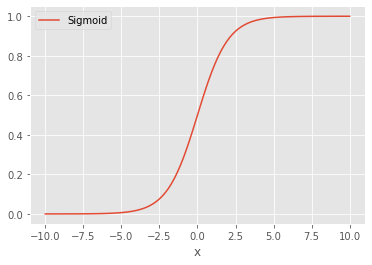

**(a) Implement the logistic sigmoid in the function `sigmoid(x)`:<span style="float:right"> (1 point)</span>**

In [ ]:
# this seems to work  - but double check!

def sigmoid(x):
    # TODO: implement the sigmoid function
    return 1 / (1+torch.exp(-x))

# try with some random inputs
torch.manual_seed(42)
x = 10 * (torch.rand(5) - 0.5)
print('x:', x)
print('sigmoid(x):', sigmoid(x))

# Try with some extreme inputs
assert sigmoid(torch.tensor(0)) == 0.5
assert sigmoid(torch.tensor(-100)) == 0
assert sigmoid(torch.tensor(100)) == 1

### Rectified linear units (ReLU)

The rectified linear unit is defined as:
\begin{align}
  f(x) = \max(0, x)
\end{align}

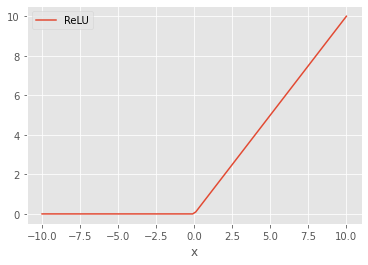

**(b) Implement the ReLU function in the functions `relu(x)`: <span style="float:right"> (1 points)</span>**

In [ ]:
def relu(x):
    # TODO: implement the relu function
    return torch.relu(x)

# try with some random inputs
torch.manual_seed(42)
x = 10 * (torch.rand(5) - 0.5)
print('x:', x)
print('relu(x):', relu(x))

# Check properties
assert all(relu(x) >= 0)
assert relu(x).shape == x.shape
assert relu(torch.tensor(0)) == 0
assert relu(torch.tensor(-5)) == 0
assert relu(torch.tensor(5)) == 5

### Comparing sigmoid and ReLU

The sigmoid and ReLU activation functions have slightly different characteristics.

**(c) Run the code below to plot the sigmoid and ReLU activation functions:**

In [ ]:
x = torch.linspace(-10, 10, 100)

plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.xlabel('x')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(x, relu(x), label='ReLU')
plt.xlabel('x')
plt.legend(loc='upper left');

**(d) Which activation function would you recommend for a network that outputs probabilities, i.e., outputs $\in [0, 1]$? Why?<span style="float:right"> (1 point)</span>**

[a] The sigmoid function, because its output is always between 0 and 1.  
[b] The ReLU function, because it ensures that the output is positive, while not distorting the output too much.  
[c] Both sigmoid and ReLU can work here.  
[d] No activation function is needed, the neural network can learn to output values in the desired range  

TODO: Select one answer:  
[a] The sigmoid function, because its output is always between 0 and 1.

### Binary cross-entropy loss

We will use the binary cross-entropy loss to train our network. This loss function is useful for binary classification.

The binary cross-entropy (BCE) is a function of the ground truth label $y \in \{0, 1\}$ and the predicted label $\hat{y} \in [0, 1]$:

\begin{align}
  \ell(y, \hat{y}) &= -(y \log{\hat{y}} + (1-y) \log(1-\hat{y})) \\
\end{align}

The BCE loss is the average of the loss function for all samples in a dataset,

\begin{align}
  L = \frac{1}{N} \sum_{i=1}^N \ell(y_i, \hat{y}_i)
\end{align}

Note: pytorch has a built in function for computing the mean.

**(e) Implement `bce_loss(y, y_hat)`:<span style="float:right"> (1 point)</span>**

In [ ]:
torch.manual_seed(42)
y = torch.randint(2, size=(5,))
y_hat = torch.rand(size=(5,))
print('y:', y)
print('y_hat:', y_hat)

In [ ]:
def bce_loss(y, y_hat):
    # TODO: implement the BCE loss
    loss = -(y*torch.log(y_hat)+(1-y)*torch.log(1-y_hat))
    return torch.mean(loss)

# try with some random inputs
torch.manual_seed(42)
y = torch.randint(2, size=(5,))
y_hat = torch.rand(size=(5,))
print('y:', y)
print('y_hat:', y_hat)
print('bce_loss(y, y_hat):', bce_loss(y, y_hat))
print()

# Properties
assert tuple(bce_loss(torch.tensor([1]), torch.tensor([0.123])).shape) == (), "The loss should be a scalar"
assert bce_loss(torch.tensor([1]), torch.tensor([0.123])) == bce_loss(torch.tensor([0]), torch.tensor([1-0.123])), "Flipping the label and prediction should give the same loss"
assert bce_loss(torch.tensor([1,1]), torch.tensor([0.123,0.123])) == bce_loss(torch.tensor([1,1]), torch.tensor([0.123,0.123])), "The loss should be the mean over all samples"

**(f) Compute the BCE loss for a perfect prediction. Is this the correct answer? <span style="float:right"> (1 point)</span>**

[a] The BCE loss is 0, which is correct.  
[b] The BCE loss is very close to 0. It is not exactly 0 because of numerical errors.  
[c] The answer is not a number, because `0 * log(0)` is undefined.  
[d] The code does not compute the correct loss, because of division by 0.  

In [ ]:
# TODO: compute loss for a perfect prediction (this would mean that y == y_hat)

y = torch.randint(2, size=(5,))
y_hat = y
print('y:', y)
print('y_hat:', y_hat)


print('bce_loss(y, y_hat):', bce_loss(y, y_hat))
print()

TODO: Select one answer:  
[c] The answer is not a number, because 0 * log(0) is undefined

In [ ]:
torch.log(torch.tensor(0.0))

The proper way to implement cross-entropy is to combine it with the logistic sigmoid activation function.
But for now we can use one of two simple ways to fix this issue:
 * Ensure that the predicted probabilities are never exactly 0 or 1. For example by scaling them to the range `[1e-6; 1-1e-6]`.
 * Or use [`torch.where`](https://pytorch.org/docs/stable/generated/torch.where.html) or indexing with `tensor[y==1]`, to implement the loss function as
$$
\ell(y, \hat{y}) =
\begin{cases}
-\log(\hat{y}) & \text{if } y = 1 \\
-\log(1 - \hat{y}) & \text{if } y = 0
\end{cases}
$$


**(g) Give an implementation of BCE loss with this issue fixed <span style="float:right"> (1 point)</span>**

In [ ]:
def bce_loss(y, y_hat):
    # Implement bce_loss to work correctly with perfect predictions
    loss = -(torch.where(y==1, torch.log(y_hat), torch.log(1-y_hat)))
    return torch.mean(loss)
    

# Test bce_loss for perfect predictions
assert bce_loss(torch.tensor([0]), torch.tensor([0])) < 2e-6
assert bce_loss(torch.tensor([1]), torch.tensor([1])) < 2e-6
assert bce_loss(torch.tensor([0]), torch.tensor([1])) > 10
assert bce_loss(torch.tensor([1]), torch.tensor([0])) > 10
# Checks from before should still hold
assert tuple(bce_loss(torch.tensor([1]), torch.tensor([0.123])).shape) == (), "The loss should be a scalar"
assert abs(bce_loss(torch.tensor([1]), torch.tensor([0.123])) - bce_loss(torch.tensor([0]), torch.tensor([1-0.123]))) < 1e-6, "Flipping the label and prediction should give the same loss"
assert bce_loss(torch.tensor([1,1]), torch.tensor([0.123,0.123])) == bce_loss(torch.tensor([1,1]), torch.tensor([0.123,0.123])), "The loss should be the mean over all samples"

Double check my implementation and maybe apply the range scaling instead!

## 1.4 Implement a one-layer model (2 points)

We will first implement a simple one-layer model with a sigmoid activation:

Given an input vector $\mathbf{x}$, weight vector $\mathbf{w}$ and bias $b$, compute the output $\hat{y}$:

\begin{align}
\tilde{y} = \mathbf{x} \cdot \mathbf{w} + b \\
\hat{y} = \sigma(\tilde{y}) \\
\end{align}

Hint: in torch inner product and matrix multiplication is denoted as `A @ B`.

**(a) Complete the implementation below:<span style="float:right"> (2 points)</span>**

In [ ]:
# initialize parameters
torch.manual_seed(42)
w = torch.randn(size=(5,))
b = torch.randn(size=[])

# implement the model
def model1(x):
    # TODO: compute y_tilde, y_hat
    y_tilde = x @ w + b
    y_hat = sigmoid(y_tilde)
    return y_hat

# test with a random input
x = torch.randn(size=(5,))

y_hat = model1(x)
print("y_hat:", y_hat)

assert tuple(y_hat.shape) == (), "There should be one output"

## 1.5 Implement a multi-layer network (5 points)

We are now ready to implement a more general neural network function.
This will follow the "network in one line" from the slides, or eq (6.19) from Bishop.

The `network` function takes an input `x`, and a list of parameters. For each layer the parameters contain weights `w`, biasses `b`, and an activation function `h`.

For each layer, we should compute a linear transformation of the previous layer's output `z`, and then apply the activation function.

The function should work on multiple samples at the same time, so `x` and `z` should be rank 2 tensors.

**(a) Complete the implementation below:<span style="float:right"> (2 points)</span>**

In [ ]:
# The network will consist of Layers that have a weight, a bias, and an activation function
Layer = namedtuple('Layer', ['weight', 'bias', 'activation'])

def network(x, layers):
    z = x
    for l, (w, b, h) in enumerate(layers):
        # Compute z^(l) given z^(l-1)
        z = h(z @ w + b)

    # Final output. Note: squeeze removes the last dimension if there is only 1 output
    y = z.squeeze(dim=-1)
    return y

# Test with a simple networks. N=2, D₀=5, D₁=10, D₂=1
torch.manual_seed(42)
params = [(torch.randn((5,10)), torch.zeros((10,)), relu)
         ,(torch.randn((10,1)), torch.zeros((1,)), sigmoid)]
x = torch.randn((2,5))
y = network(x, params)
print(y)
assert tuple(y.shape) == (2,), "Expected two samples and one output channel"

For initializing the parameters and describing the network architecture, we can make a helper function.
This function should initialize the parameters for a single layer.

* You should initialize the weights using He initialization. That is: drawn from a normal distribution with the variance as described in the slides.
* You should initialize the biases to zero

**(b) Complete the implementation below:<span style="float:right"> (3 points)</span>**

In [ ]:
epsilon = torch.normal(mean=0.0, std=math.sqrt(2/10), size=(1,))


In [ ]:
def make_layer(d0, d1, activation):
    """
    Create the parameters for a layer in the neural network, with input size d0, and output size d1.
    Weights are initialized with He initialization.
    Biases are initialized to 0.
    """
    # Choose initialization scale. Use He initialization - weights are initialized from a normal distribution with a mean of 0 and a SD of squareroot(2/n)
    #  epsilon = torch.normal(mean=0.0, std=math.sqrt(2/d0),size = (1,))
    epsilon = math.sqrt(2/d0)

    # Initialize weights randomly
    w = epsilon * torch.randn(d0, d1)

    # Initialize biases to zero
    b = torch.zeros(d1)
    return Layer(w.double(), b.double(), activation)

# Tests
assert isinstance(make_layer(5, 10, sigmoid), Layer)
assert tuple(make_layer(5, 10, sigmoid).weight.shape) == (5,10), "Weight has the wrong shape"
assert tuple(make_layer(5, 10, sigmoid).bias.shape) == (10,), "Bias has the wrong shape"
assert abs(torch.mean(make_layer(2, 100000, sigmoid).weight) - 0) < 1e-2, "Weights should have mean 0"
assert abs(torch.std(make_layer(2, 100000, sigmoid).weight) - 1) < 1e-2, "Scale of the weights is wrong"
assert abs(torch.std(make_layer(8, 100000, sigmoid).weight) - 0.5) < 1e-2, "Scale of the weights is wrong"
assert all(make_layer(1, 100, sigmoid).bias == 0), "Biases should be initialized to zero"

## 1.6 Training the network (11 points)

We load a simple dataset with 360 handwritten digits.

Each sample has $8 \times 8$ pixels, arranged as a 1D vector of 64 features.

We create a binary classification problem with the label 0 for the digits 0 to 4, and 1 for the digits 5 to 9.

**(a) Read and run the code below.**

`torch.tensor.double()` - what does it do?
to cast a float tensor to a double tensor


In [ ]:
# load the first two classes of the digits dataset
dataset = sklearn.datasets.load_digits()

# create a binary classification problem
digits_x = torch.tensor(dataset['data']).double()
digits_y = torch.tensor(dataset['target'] < 5).double()

# plot some of the digits
plt.figure(figsize=(10, 2))
plt.imshow(torch.hstack([digits_x[i].reshape(8, 8) for i in range(10)]), cmap='gray')
plt.grid(False)
plt.tight_layout()
plt.axis('off')

# normalize the values to mean 0, standard deviation 1
digits_x -= torch.mean(digits_x)
digits_x /= torch.std(digits_x)

# print some statistics
print('digits_x.shape:', digits_x.shape)
print('digits_y.shape:', digits_y.shape)
print('min, max values:', torch.min(digits_x).item(), torch.max(digits_x).item())
print('labels:', torch.unique(digits_y))

We divide the dataset in a train and a validation set.

In [ ]:
# make a 50%/50% train/validation split
train_prop = 0.5
n_train = int(digits_x.shape[0] * train_prop)

# shuffle the datapoints
torch.manual_seed(42)
idxs = torch.randperm(digits_x.shape[0])

# take a subset
split_x = {'train': digits_x[idxs[:n_train]],
           'val':   digits_x[idxs[n_train:]]}
split_y = {'train': digits_y[idxs[:n_train]],
           'val':   digits_y[idxs[n_train:]]}

print('Training samples:', split_x['train'].shape[0])
print('Validation samples:', split_x['val'].shape[0])

We will now implement a function that trains the network. We will first define some helper functions for working with gradients.
Note that pytorch actually has this functionality built in, but in this assignment we are using our own definitions for clarity.

**(b) Read and run the code below.**

Make sure that you undestand what each of these functions is used for. You should not change these functions.

In [ ]:
def parameters(layers):
    """
    Return a list of all trainable parameters in a list of layers
    """
    parameters = []
    for layer in layers:
        parameters.append(layer.weight)
        parameters.append(layer.bias)
    return parameters

def enable_gradients(layers):
    """
    Enable gradient computation for the model parameters.
    """
    for param in parameters(layers):
        param.requires_grad_()

def add_gradients(params, step_size):
    """
    Update the parameters: θ ← θ + step_size * ∇_θ
    """
    with torch.no_grad():   # disables gradient calculation
        for param in parameters(layers):
            if any(param.grad.flatten().isnan()):
                raise Exception("Gradients are nan, something went wrong")
            param += step_size * param.grad

def clear_gradients(params):
    """
    Reset the computed gradients.
    """
    for param in parameters(layers):
        param.grad = None

`with torch.no_grad()`
Normally PyTorch tracks all operations on tensors that require gradients so it can compute higher-order derivatives.
Here, we are manually updating the parameters. We don't want PyTorch to track this, otherwise it would mess up the computation graph

Next we will implement a function that evaluates the performance on the validation set:

**(c) Complete the code below: <span style="float:right"> (2 points)</span>**

In [ ]:
def accuracy(y, y_hat):
    """Compute accuracy"""
    return torch.mean(((y > 0.5) == (y_hat > 0.5)).float())

def evaluate(params, x, y):
    """
    Evaluate the performance of the network on a dataset (x, y).
    Returns: loss and accuracy.
    """
    with torch.no_grad(): # tells torch we don't need gradients
        # TODO: compute y_hat, bce_loss, and accuracy
        y_hat = x.double()  # make sure input is of correct type
        
        for layer in params:
            y_hat = layer.activation(y_hat @ layer.weight + layer.bias)
        #     y_hat = x @ layer.weight + layer.bias # I don't think this will work
        loss  = bce_loss(y, y_hat)
        acc   = accuracy(y, y_hat)
        return loss.item(), acc.item()

**(d) Run the code below to compute the loss and accuracy of an untrained network: <span style="float:right"> (no points)</span>**

In [ ]:
# Initialize parameters
torch.manual_seed(42)
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]
evaluate(layers, split_x['val'], split_y['val'])

Now we can define a training loop. 

For each epoch, the function `fit` loops over all minibatches in the training set and updates the network parameters. It will then compute the loss and accuracy for the validation samples. Finally, it will plot the learning curves.

The actual training happens in `train_epoch`. There is still some work to be done there.

**(e) Complete the code below: <span style="float:right"> (5 points)</span>**

In [ ]:
def train_epoch(layers, x_train, y_train, learning_rate, batch_size):
    """
    One epoch of training with gradient descent.
    """
    n = len(x_train)
    if batch_size is None or batch_size > n:
        batch_size = n
    num_batches = n // batch_size
    random_order = torch.randperm(n)
    
    loss_total = 0
    accuracy_total = 0

    for step in range(num_batches):
        # Minibatch
        x_batch = x_train[random_order[step*batch_size : (step+1)*batch_size]].double()
        y_batch = y_train[random_order[step*batch_size : (step+1)*batch_size]].double()

        # Forward pass
        y_hat = x_batch
        for layer in layers:
            y_hat = layer.activation(y_hat @ layer.weight + layer.bias)
            y_hat = y_hat.squeeze(-1)  

        # Compute loss
        loss = bce_loss(y_batch, y_hat)
        acc = accuracy(y_batch, y_hat)

        # Backward pass
        loss.backward()
        
        # Gradient descent update
        for layer in layers:
            layer.weight.data -= learning_rate * layer.weight.grad
            layer.bias.data   -= learning_rate * layer.bias.grad
            # Zero gradients for next batch
            layer.weight.grad.zero_()
            layer.bias.grad.zero_()

        # Compute total loss
        loss_total += loss.item()
        accuracy_total += acc.item()

    return loss_total / num_batches, accuracy_total / num_batches




def fit(layers, x, y, epochs=25, **kwargs):
    """
    Optimize the the parameters with gradient descent
    """
    # Initialize the loss and accuracy history
    log = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    #loss_hist = {'train': [], 'val': []}
    #accuracy_hist = {'train': [], 'val': []}
    
    # Enable gradients for the parameters
    enable_gradients(layers)
    
    # Table of results per epoch
    print(f'| Epoch | Train loss | Validation loss | Train accuracy | Validation accuracy |')
    print( '|-------|------------|-----------------|----------------|---------------------|')
    
    for epoch in range(1, epochs+1):
        # Training
        train_loss, train_acc = train_epoch(layers, x['train'], y['train'], **kwargs)
        log['epoch'].append(epoch)
        log['train_loss'].append(train_loss)
        log['train_acc'].append(train_acc)
        
        # Validation
        val_loss, val_acc = evaluate(layers, x['val'], y['val'])
        log['val_loss'].append(val_loss)
        log['val_acc'].append(val_acc)

        print(f'| {epoch:5} | {train_loss:10.3f} | {val_loss:15.3f} | {train_acc:14.3f} | {val_acc:19.3f} |')
    
    # Plot the learning curves
    fig = plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    for phase in ['train', 'val']:
        plt.plot(log['epoch'], log[phase+'_loss'], label=phase)
    plt.title('BCE loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    for phase in ['train', 'val']:
        plt.plot(log['epoch'], log[phase+'_acc'], label=phase)
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

We will define a two-layer network:
* A layer that maps the 64 features of the input to 32 features.
* A ReLU activation function.
* A layer that maps the 32 features to the 1 output features.
* A sigmoid activation function that maps the output to [0, 1].

**(f) Train the network and inspect the results. Tune the hyperparameters to get a good result. Keep track of all experiments that you perform.<span style="float:right"> (1 point)</span>**

(Hint: it is possible to get validation accuracy ≥ 0.95)

Results of runs:
| Learning rate | Batch size | Epochs | Train loss | Validation loss | Train accuracy | Validation accuracy |
|---------------|------------|--------|------------|-----------------|----------------|---------------------|
| 0             |         10 |     25 | ...        | ....            | ...            | ...                 |
    0.1                   10       25          0.06         3.994           1.0             0.5
    0.002                 10       25          0.34         0.97            0.908            0.501

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 25,
learning_rate = 0.1,
batch_size = 10)

# Note: Add more cells below if you want to keep runs with different hyperparameters.
#       Make sure to also copy the initialization.

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 25,
learning_rate = 0.002,
batch_size = 10)

# Note: Add more cells below if you want to keep runs with different hyperparameters.
#       Make sure to also copy the initialization.

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 50,
learning_rate = 0.08,
batch_size = 10)

**(g) Perform experiments with varying learning rate, and add them to the table above. Which of the following statements is true?<span style="float:right"> (1 point)</span>**

[a] The learning rate does not have a big impact on the model's accuracy.  
[b] If the learning rate is too low, the training will never reach a low training loss, even with more epochs.  
[c] The training will converge, regardless of the learning rate, but the model can be better or worse.  
[d] Models trained with a higher learning rate tend to generalize better.  

TODO: Select one answer:  
[c]

**(h) Perform experiments with varying batch size, and add them to the table above. Which of the following statements is true?<span style="float:right"> (1 point)</span>**

[a] There is a large range of batch sizes with similar performance.  
[b] If the batch size is too high, the training never converges to a good model.  
[c] If the batch size is too low, the loss becomes noisy and training does not converge.  
[d] Performance is sensitive to the batch size, and it is important to select the right value.  

TODO: Select one answer:  
[a]

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 50,
learning_rate = 0.01,
batch_size = 5)

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 50,
learning_rate = 0.01,
batch_size = 100)

**(i) Perform experiments with varying number of epochs, and add them to the table above. Which of the following statements is true?<span style="float:right"> (1 point)</span>**

[a] The number of epochs is not important for the performance of the model.  
[b] If the number of epochs is too low, training becomes slower.  
[c] After a certain number of ecochs the validation accuracy will start to decrease.  
[d] After a certain number of ecochs the validation loss will start to increase.  

Note: To save time, you can use results from part way through the training process to get metrics for different epochs.

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 100,
learning_rate = 0.01,
batch_size = 100)

In [ ]:
# Fix seed for reproducable runs
torch.manual_seed(42)

# Initialize parameters
layers = [
    make_layer(64, 32, relu),
    make_layer(32, 1, sigmoid),
]

# TODO: tune the hyperparameters

fit(layers, split_x, split_y,
epochs = 10,
learning_rate = 0.01,
batch_size = 100)

TODO: Select one answer:  
[d]

## 1.7 Varying the architecture (6 points)

**(a) Create and train a network with a single layer with sigmoid activation:<span style="float:right"> (1 point)</span>**

In [ ]:
# TODO: Your code here.

**(b) Compare the results of this single-layer network with those of the network you trained before.<span style="float:right"> (1 point)</span>**

[a] The single-layer network shows less overfitting, so it is better.  
[b] The single-layer network is not complex enough to fit the data, which results in a lower accuracy.  
[c] The single-layer network converges slower, and so it needs more epochs to reach the same loss.  
[d] The single-layer network model is less stable than the two-layer model, and it has lower validation accuracy.  

TODO: Select one answer:  
[a/b/c/d]

**(c) Repeat the experiment with a network with two linear layers, without an activation function in between, followed by a sigmoid activation.<span style="float:right"> (1 point)</span>**

You can make a layer without an activation function by using the identity function as the activation function: `lambda x: x`.

In [ ]:
# TODO: Your code here.

**(d) How does the performance of this network compare with the previous networks. Can you explain this result? What is the influence of the activation functions in the network?<span style="float:right"> (1 point)</span>**

TODO: Your answer here.

**(e) One way to improve the performance of a neural network is by increasing the number of layers. Try a deeper network (e.g., a network with four layers) to see if this outperforms the previous networks.<span style="float:right"> (1 point)</span>**

In [ ]:
# TODO: Your code here.

**(f) Discuss your findings. Were you able to obtain a perfect classification? Explain the learning curves.<span style="float:right"> (1 point)</span>**

TODO: Your answer here.

## 1.8 Final questions (6 points)

You now have some experience training neural networks. Time for a few final questions.

**(a) What is the role of learning rate in gradient descent? What can go wrong if the learning rate is set incorrectly?<span style="float:right"> (2 points)</span>**

TODO: Your answer here.

The learning rates plays an important part in gradient, if its too large, then the step size on each iteration of updating the model parameters is large and this can cause the algorithm to overshoot and miss the global minimum. On the other hand, a very low learning rate the training time becomes longer and successful congvergence might not be guaranteed.

**(b) What is the role of the minibatch size in SGD? Explain the downsides of a minibatch size that is too small or too high.<span style="float:right"> (2 points)</span>**

TODO: Your answer here.

The size of the minibatch affects the speed and efficiency in SDG. However, smaller mini-batch sizes result in lower loss values. If there are too high, there is not much of a difference compared to doing gradient descent on the entire data set. 
Small minibatch lead to noisier gradient estimates, whereas large minibatch lead to smoother estimates (but require also more memory.)

**(c) In the linear layer, we initialized the weights $w$ with random values, but we initialized the bias $b$ with zeros. What would happen if the weights $w$ were initialised as zeros? Why is this not a problem for the bias?<span style="float:right"> (2 points)</span>**

TODO: Your answer here.

This refers to the symmetry problem, where given that all weights are initialized with the same initial value (for example 0), then when doing backpropagation, all weights will get the same gradient, and hence the same update (this prevents them from learning unique features). The bias term is not affected, since it only introduces shifts to the activation function.

## The end

Well done! Please double check the instructions at the top before you submit your results.

*This assignment has 42 points.*
<span style="float:right;color:#aaa;font-size:10px;"> Version 6f4f94e / 2025-11-05</span>